In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from util.TSB_AD.metrics import metricor
from util.TSB_AD.slidingWindows import find_length #,plotFig, printResult
from sklearn.preprocessing import MinMaxScaler
import os
import sys
from sklearn import metrics

from tqdm.notebook import tqdm
import math
import arff
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
def running_mean(x,N):
	return (np.cumsum(np.insert(x,0,0))[N:] - np.cumsum(np.insert(x,0,0))[:-N])/N

def read_arff(filename):
    """
    Find ndarray corresponding to data and labels from arff data
    """
    arff_content = arff.load(f.replace(',\n', '\n') for f in open(filename, 'r'))
    arff_data = arff_content['data']
    data = np.array([i[:1] for i in arff_data])
    anomaly_labels = np.array([i[-1] for i in arff_data])
    anomaly_labels = anomaly_labels.reshape((len(anomaly_labels),1))
    return data.astype(float), anomaly_labels.astype(float)

peak_adj_columns = ['AUC', 'Precision', 'Recall', 'F1', 'TH', 'RPrecision', 'RRecall', 'RF1', 'PaK', 'F1_adj', 'Precision_adj', 'Recall_adj', 'roc_auc_adj']

# the below function is taken from OmniAnomaly code base directly
def adjust_predicts(score, label,
                    threshold=None,
                    pred=None,
                    calc_latency=False):
    """
    Calculate adjusted predict labels using given `score`, `threshold` (or given `pred`) and `label`.
    Args:
        score (np.ndarray): The anomaly score
        label (np.ndarray): The ground-truth label
        threshold (float): The threshold of anomaly score.
            A point is labeled as "anomaly" if its score is lower than the threshold.
        pred (np.ndarray or None): if not None, adjust `pred` and ignore `score` and `threshold`,
        calc_latency (bool):
    Returns:
        np.ndarray: predict labels
    """
    if len(score) != len(label):
        raise ValueError("score and label must have the same length")
    score = np.asarray(score)
    label = np.asarray(label)
    latency = 0
    # print(type(score), score.dtype, threshold)
    if pred is None:
        predict = score > threshold
    else:
        predict = pred
    actual = label > 0.1
    anomaly_state = False
    anomaly_count = 0
    for i in range(len(score)):
        if actual[i] and predict[i] and not anomaly_state:
                anomaly_state = True
                anomaly_count += 1
                for j in range(i, 0, -1):
                    if not actual[j]:
                        break
                    else:
                        if not predict[j]:
                            predict[j] = True
                            latency += 1
        elif not actual[i]:
            anomaly_state = False
        if anomaly_state:
            predict[i] = True
    if calc_latency:
        return predict, latency / (anomaly_count + 1e-4)
    else:
        return predict

def calc_point2point(predict, actual):
    """
    calculate f1 score by predict and actual.
    Args:
        predict (np.ndarray): the predict label
        actual (np.ndarray): np.ndarray
    """
    TP = np.sum(predict * actual)
    TN = np.sum((1 - predict) * (1 - actual))
    FP = np.sum(predict * (1 - actual))
    FN = np.sum((1 - predict) * actual)
    precision = TP / (TP + FP + 0.00001)
    recall = TP / (TP + FN + 0.00001)
    f1 = 2 * precision * recall / (precision + recall + 0.00001)
    try:
        roc_auc = metrics.roc_auc_score(actual, predict)
    except:
        roc_auc = 0
    return f1, precision, recall, TP, TN, FP, FN, roc_auc

def peakf1_acc(label, score, plot_AUC=False, alpha=0.2):
    grader = metricor()
    result = pd.DataFrame(columns=peak_adj_columns)
    if np.sum(label) != 0:
        auc = metrics.roc_auc_score(label, score)

        # plor ROC curve
        fpr, tpr, _ = metrics.roc_curve(label, score)
        pr, re, thresholds = metrics.precision_recall_curve(label, score)
        # print(f'LEN: {len(thresholds)}')
        if plot_AUC:
            dp = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc)
            dp.plot()
        
        peak_f1, peak_ind = np.nanmax(2*(pr*re)/(pr+re)), np.nanargmax(2*(pr*re)/(pr+re))
        # print(peak_f1, peak_ind)
        peak_ths = thresholds[peak_ind] 
        # print(peak_ths)

        #range anomaly 
        preds = score > peak_ths
        Rrecall, ExistenceReward, OverlapReward = grader.range_recall_new(label, preds, alpha)
        Rprecision = grader.range_recall_new(preds, label, 0)[0]

        if Rprecision + Rrecall==0:
            Rf=0
        else:
            Rf = 2 * Rrecall * Rprecision / (Rprecision + Rrecall)

        # top-k
        k = int(np.sum(label))
        threshold = np.percentile(score, 100 * (1-k/len(label)))

        p_at_k = np.where(score > threshold)[0]
        TP_at_k = sum(label[p_at_k])
        precision_at_k = TP_at_k/k

        ## Adjustment csae
        pred_adj = adjust_predicts(score, label,
                threshold=peak_ths,
                pred=None,
                calc_latency=False)
        
        f1_adj, pr_adj, re_adj, _, _, _, _, auc_adj = calc_point2point(pred_adj, label)

        result.loc[0] = [auc, pr[peak_ind], re[peak_ind], peak_f1, peak_ths, Rprecision, Rrecall, Rf, precision_at_k, f1_adj, pr_adj, re_adj, auc_adj]
        return result
    
def result_f1_acc(methods, scores, label, ths = None):
    result_org = pd.DataFrame(columns=['method'] + peak_adj_columns)
    j = 0
    for i, method in enumerate(methods):
        # r_tmp = get_acc(label.reshape(-1)[:len(scores[i])], np.array(scores[i]), slidingWindow, ths)
        r_tmp = peakf1_acc(label.reshape(-1)[:len(scores[i])], np.array(scores[i]), plot_AUC=False)
        if r_tmp is not None:
            result_org.loc[j] = [method] + list(r_tmp.loc[0])
        else:
            result_org.loc[j] = [method] + [0]*len(peak_adj_columns)
        j+=1

    # display(result_org)
    return result_org

### Figs

In [3]:
methods = ['NormA', 'SAND']
data_folders = []
data_folders.append('/data/test_weather/org')
data_folders.append('/data/test_weather/n_drift')
data_folders.append('/data/test_weather/p_drift')
data_folders.append('/data/test_weather_mod/org')
data_folders.append('/data/test_weather_mod/n_drift')
data_folders.append('/data/test_weather_mod/p_drift')

x_p_d = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
x_n_d = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10]

slws, names = [], []
fns = []
for dir_data in data_folders:
    dir = os.getcwd() + dir_data
    all_files = os.listdir(dir)
    filenames = [file for file in all_files if file.endswith('.arff')]
    print(filenames)
    org_labels = []
    result_org = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)

    name_f = dir_data.split('/')[-1]
    with open(f'{dir}/result_score_{name_f}_2.pkl', 'rb') as f:
        org_scores = pickle.load(f)

    slw = []
    fn=[]
    names.append(name_f)
    for i, file in enumerate(filenames):
        data, label = read_arff(f'{dir}/{file}')
        data = data.reshape(-1)
        slidingWindow = find_length(data[:10000])
        slw.append(slidingWindow)
        fn.append(file)
        org_labels.append(label)

        # for j, method in enumerate(methods):
        r_tmp = result_f1_acc(methods, org_scores[i], label.flatten())
        r_tmp['file'] = file
        result_org = pd.concat([result_org, r_tmp])

    slws.append(slw)
    fns.append(fn)
    if name_f == 'n_drift':
        result_org['n'] = result_org['file'].str.extract(r'_n(\d+)_').astype(int)
    elif name_f == 'p_drift':
        result_org['p'] = result_org['file'].str.extract(r'_p(\d+)_').astype(int)

    result_org.to_csv(f'{dir}/result_{name_f}_2.csv', index=None)

['NO_temperature_anomaly.arff', 'DE_temperature_anomaly.arff', 'GR_temperature_anomaly.arff']
['WeatherTest_n_d_grad_p19_n2_b50.arff', 'WeatherTest_n_d_grad_p19_n8_b50.arff', 'WeatherTest_n_d_grad_p19_n5_b40.arff', 'WeatherTest_n_d_grad_p19_n6_b42.arff', 'WeatherTest_n_d_grad_p19_n11_b45.arff', 'WeatherTest_n_d_grad_p19_n4_b50.arff', 'WeatherTest_n_d_grad_p19_n10_b50.arff', 'WeatherTest_n_d_grad_p19_n9_b44.arff', 'WeatherTest_n_d_grad_p19_n6_b50.arff', 'WeatherTest_n_d_grad_p19_n3_b33.arff']
['WeatherTest_p_d_grad_p14_n5_b40.arff', 'WeatherTest_p_d_grad_p9_n5_b40.arff', 'WeatherTest_p_d_grad_p29_n5_b40.arff', 'WeatherTest_p_d_grad_p39_n5_b40.arff', 'WeatherTest_p_d_grad_p19_n5_b40.arff', 'WeatherTest_p_d_grad_p4_n5_b40.arff', 'WeatherTest_p_d_grad_p24_n5_b40.arff', 'WeatherTest_p_d_grad_p34_n5_b40.arff', 'WeatherTest_p_d_grad_p44_n4_b40.arff']
['GR_temperature_anomaly_v1_o0.1_m1.5_p1_mod.arff', 'GR_temperature_anomaly.arff', 'GR_temperature_anomaly_v0.5_o0.5_m0.5_p1_mod.arff', 'GR_temp

In [4]:
methods = ['NormA', 'SAND']
dir_data = '/data/test_weather/p_drift'
dir = os.getcwd() + dir_data
name_f = dir_data.split('/')[-1]

all_files = os.listdir(dir)
filenames = [file for file in all_files if file.endswith('.arff')]

with open(f'{dir}/result_score_{name_f}.pkl', 'rb') as f:
    org_scores = pickle.load(f)

### For reading DAMP results by Matlab code 

In [5]:
for dir_data in data_folders:
    dir = os.getcwd() + dir_data
    all_files = os.listdir(dir)
    filenames = [file for file in all_files if file.endswith('score.csv')]
    filenames.sort()
    print(filenames)
    name_f = dir_data.split('/')[-1]

    filenames_data = [file for file in all_files if file.endswith('arff')]
    filenames_data.sort()
    print(filenames_data)

    result_org_damp = pd.DataFrame(columns=['file', 'method'] + peak_adj_columns)
    scores, labels, datas, sls = [], [], [], []

    for i, (file, file_data) in enumerate(zip(filenames, filenames_data)):
        df = pd.read_csv(f'{dir}/{file}')
        score = df.iloc[:,0].to_numpy()

        slidingWindow = 24
        # label = org_labels[i]
        data, label = read_arff(f'{dir}/{file_data}')
        # slidingWindow = find_length(data.reshape(-1)[:10000])
        # sls.append(slidingWindow)
        # print(slidingWindow)
        datas.append(data)
        labels.append(label)

        score = running_mean(score, slidingWindow)
        score = np.array([score[0]]*math.ceil((slidingWindow-1)) + list(score))
        scores.append(score)

        r_tmp = result_f1_acc(['DAMP'], [score], label.flatten())
        r_tmp['file'] = file
        result_org_damp = pd.concat([result_org_damp, r_tmp])

    # result_org_damp.to_csv(f'{dir}/damp_{name_f}.csv', index=None)
    if name_f == 'n_drift':
        result_org_damp['n'] = result_org_damp['file'].str.extract(r'_n(\d+)_').astype(int)
        print('n')
    elif name_f == 'p_drift':
        result_org_damp['p'] = result_org_damp['file'].str.extract(r'_p(\d+)_').astype(int)
        print('p')
    result_org_damp.to_csv(f'{dir}/damp_result_{name_f}.csv', index=None)

['DE_temperature_anomaly_score.csv', 'GR_temperature_anomaly_score.csv', 'NO_temperature_anomaly_score.csv']
['DE_temperature_anomaly.arff', 'GR_temperature_anomaly.arff', 'NO_temperature_anomaly.arff']
['WeatherTest_n_d_grad_p19_n10_b50_score.csv', 'WeatherTest_n_d_grad_p19_n11_b45_score.csv', 'WeatherTest_n_d_grad_p19_n2_b50_score.csv', 'WeatherTest_n_d_grad_p19_n3_b33_score.csv', 'WeatherTest_n_d_grad_p19_n4_b50_score.csv', 'WeatherTest_n_d_grad_p19_n5_b40_score.csv', 'WeatherTest_n_d_grad_p19_n6_b42_score.csv', 'WeatherTest_n_d_grad_p19_n6_b50_score.csv', 'WeatherTest_n_d_grad_p19_n8_b50_score.csv', 'WeatherTest_n_d_grad_p19_n9_b44_score.csv']
['WeatherTest_n_d_grad_p19_n10_b50.arff', 'WeatherTest_n_d_grad_p19_n11_b45.arff', 'WeatherTest_n_d_grad_p19_n2_b50.arff', 'WeatherTest_n_d_grad_p19_n3_b33.arff', 'WeatherTest_n_d_grad_p19_n4_b50.arff', 'WeatherTest_n_d_grad_p19_n5_b40.arff', 'WeatherTest_n_d_grad_p19_n6_b42.arff', 'WeatherTest_n_d_grad_p19_n6_b50.arff', 'WeatherTest_n_d_grad

### Final fig

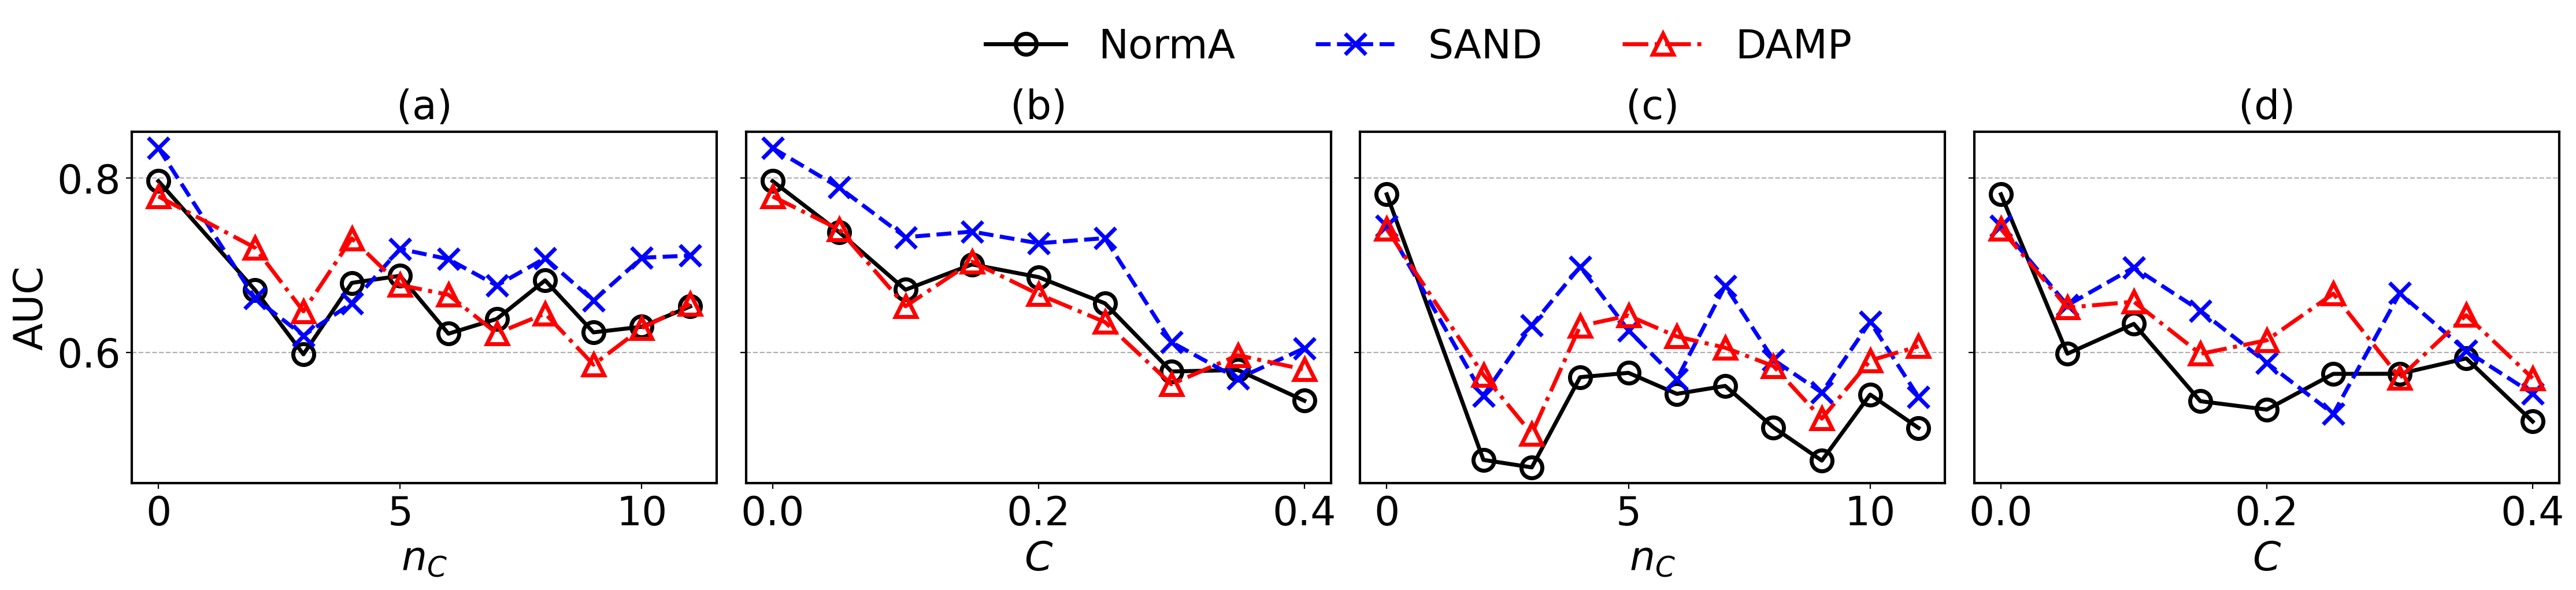

In [6]:
result_org_r = pd.read_csv('./data/test_weather/org/result_org_2.csv', index_col=None)
result_n_drift_r = pd.read_csv('./data/test_weather/n_drift/result_n_drift_2.csv', index_col=None)
result_p_drift_r = pd.read_csv('./data/test_weather/p_drift/result_p_drift_2.csv', index_col=None)

result_org = pd.read_csv('./data/test_weather_mod/org/result_org_2.csv', index_col=None)
result_n_drift = pd.read_csv('./data/test_weather_mod/n_drift/result_n_drift_2.csv', index_col=None)
result_p_drift = pd.read_csv('./data/test_weather_mod/p_drift/result_p_drift_2.csv', index_col=None)

result_org_damp = pd.read_csv('./data/test_weather/org/damp_org.csv', index_col=None)
result_n_drift_r_damp= pd.read_csv('./data/test_weather/n_drift/damp_result_n_drift.csv', index_col=None)
result_p_drift_r_damp= pd.read_csv('./data/test_weather/p_drift/damp_result_p_drift.csv', index_col=None)

result_org_damp_mod= pd.read_csv('./data/test_weather_mod/org/damp_org.csv', index_col=None)
result_n_drift_mod_damp= pd.read_csv('./data/test_weather_mod/n_drift/damp_result_n_drift.csv', index_col=None)
result_p_drift_mod_damp= pd.read_csv('./data/test_weather_mod/p_drift/damp_result_p_drift.csv', index_col=None)

metric = 'AUC'
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.linewidth'] = 1.5

methods = ['NormA', 'SAND', 'DAMP']
markers = ['o', 'x', '^']
lines = ['-', '--', '-.']
colors = ['black', 'blue', 'red']

x_n_d = [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
x_p_d = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

result_p_drift_r = result_p_drift_r[result_p_drift_r['p'] !=44]
result_p_drift_r_damp = result_p_drift_r_damp[result_p_drift_r_damp['p'] != 44]
# result_p_drift_r_damp = result_p_drift_r_damp[result_p_drift_r_damp['p'] != 49]

result_p_drift = result_p_drift[result_p_drift['p']!=44]
result_p_drift_mod_damp = result_p_drift_mod_damp[result_p_drift_mod_damp['p'] != 44]
# result_p_drift_mod_damp = result_p_drift_mod_damp[result_p_drift_mod_damp['p'] != 49]

fig, axes = plt.subplots(1, 4, figsize=(25,4), sharey=True)
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.96, top=0.88, wspace=0.05, hspace=0.1)
ax_nr = axes[0]
ax_pr = axes[1]
ax_n = axes[2]
ax_p = axes[3]

markersize = 13
linewidth= 2.5

for i, m in enumerate(methods):
    if m == 'DAMP':
        ax_nr.plot(x_n_d, [np.mean(result_org_damp.groupby('method').get_group(m)[metric])] + list(result_n_drift_r_damp.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i], mfc='none', mec=colors[i], mew=linewidth, markersize=markersize, linewidth=linewidth, label=m)
        ax_pr.plot(x_p_d, [np.mean(result_org_damp.groupby('method').get_group(m)[metric])] + list(result_p_drift_r_damp.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i], mfc='none', mec=colors[i], mew=linewidth, markersize=markersize, linewidth=linewidth,label=m)
        ax_n.plot(x_n_d, [np.mean(result_org_damp_mod.groupby('method').get_group(m)[metric])] + list(result_n_drift_mod_damp.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i], mew=linewidth, markersize=markersize, linewidth=linewidth,label=m)
        ax_p.plot(x_p_d, [np.mean(result_org_damp_mod.groupby('method').get_group(m)[metric])] + list(result_p_drift_mod_damp.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
    else:
        ax_nr.plot(x_n_d, [np.mean(result_org_r.groupby('method').get_group(m)[metric])] + list(result_n_drift_r.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i], mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
        ax_pr.plot(x_p_d, [np.mean(result_org_r.groupby('method').get_group(m)[metric])] + list(result_p_drift_r.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
        ax_n.plot(x_n_d, [np.mean(result_org.groupby('method').get_group(m)[metric])] + list(result_n_drift.groupby('method').get_group(m).sort_values(by='n')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none', mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth,label=m)
        ax_p.plot(x_p_d, [np.mean(result_org.groupby('method').get_group(m)[metric])] + list(result_p_drift.groupby('method').get_group(m).sort_values(by='p')[metric]), marker=markers[i], linestyle=lines[i], color=colors[i],mfc='none',mec=colors[i],mew=linewidth,  markersize=markersize, linewidth=linewidth, label=m)
# ax_nr.set_title(f"Drift injection using 3-different regional data", x=1.1, y=1.03, fontsize=25)
# ax_pr.set_title(rf"$\mathbf{{o-modulation}}$", y=1.2, fontsize=20)
# ax_n.set_title(f"Drift injection using 3-different modulation", x=1.1,y=1.03, fontsize=25)
# ax_p.set_title(rf"$\mathbf{{o-modulation}}$", y=1.2, fontsize=20)
ax_nr.set_title('(a)', y=1.01, fontsize=25)
ax_pr.set_title('(b)', y=1.01, fontsize=25)
ax_n.set_title('(c)', y=1.01 , fontsize=25)
ax_p.set_title('(d)', y=1.01 , fontsize=25)
ax_nr.set_xlabel(r'$n_C$')
ax_n.set_xlabel(r'$n_C$')
ax_nr.set_ylabel(metric)

ax_pr.set_xlabel(r'$C$')
ax_p.set_xlabel(r'$C$')
ax_nr.legend(ncol=3, loc='upper center', frameon =False, fontsize=25, bbox_to_anchor=(2.2, 1.4))

for ax in axes.flat:
    # ax.set_ylim(y_min, y_max)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=1)

plt.savefig('./png/comparison_weather2.png', bbox_inches='tight')

In [7]:
pd.options.display.float_format = '{:.2f}'.format

ecg_org =result_org_r.groupby('method').mean()
ecg_org_damp =result_org_damp.groupby('method').mean()
auc_n_drift_norma_r = result_n_drift_r.groupby('method').get_group('NormA').sort_values(by='n').set_index('n')
auc_n_dirft_sand_r = result_n_drift_r.groupby('method').get_group('SAND').sort_values(by='n').set_index('n')
auc_n_dirft_damp_r = result_n_drift_r_damp.groupby('method').get_group('DAMP').sort_values(by='n').set_index('n')

# ecg_org =result_org_r.groupby('method').mean()
# ecg_org_damp =result_org_damp.groupby('method').mean()
# auc_n_drift_norma_r = result_p_drift_r.groupby('method').get_group('NormA').sort_values(by='p').set_index('p')
# auc_n_dirft_sand_r = result_p_drift_r.groupby('method').get_group('SAND').sort_values(by='p').set_index('p')
# auc_n_dirft_damp_r = result_p_drift_r_damp.groupby('method').get_group('DAMP').sort_values(by='p').set_index('p')

# ecg_org =result_org.groupby('method').mean()
# ecg_org_damp =result_org_damp_mod.groupby('method').mean()
# auc_n_drift_norma_r = result_n_drift.groupby('method').get_group('NormA').sort_values(by='n').set_index('n')
# auc_n_dirft_sand_r = result_n_drift.groupby('method').get_group('SAND').sort_values(by='n').set_index('n')
# auc_n_dirft_damp_r = result_n_drift_mod_damp.groupby('method').get_group('DAMP').sort_values(by='n').set_index('n')

# ecg_org =result_org.groupby('method').mean()
# ecg_org_damp =result_org_damp_mod.groupby('method').mean()
# auc_n_drift_norma_r = result_p_drift.groupby('method').get_group('NormA').sort_values(by='p').set_index('p')
# auc_n_dirft_sand_r = result_p_drift.groupby('method').get_group('SAND').sort_values(by='p').set_index('p')
# auc_n_dirft_damp_r = result_p_drift_mod_damp.groupby('method').get_group('DAMP').sort_values(by='p').set_index('p')

display((ecg_org['AUC'].loc['NormA'] - auc_n_drift_norma_r[['AUC']]) / ecg_org['AUC'].loc['NormA'])
display((ecg_org['AUC'].loc['SAND'] - auc_n_dirft_sand_r[['AUC']]) / ecg_org['AUC'].loc['SAND'])
display((ecg_org_damp['AUC'].loc['DAMP'] - auc_n_dirft_damp_r[['AUC']]) / ecg_org_damp['AUC'].loc['DAMP'])
display((auc_n_dirft_sand_r[['AUC']]-auc_n_drift_norma_r[['AUC']])/auc_n_drift_norma_r[['AUC']])

,AUC
n,
2,0.16
3,0.25
4,0.15
5,0.14
6,0.22
6,0.20
8,0.14
9,0.22
10,0.21


,AUC
n,
2,0.21
3,0.26
4,0.21
5,0.14
6,0.15
6,0.19
8,0.15
9,0.21
10,0.15


,AUC
n,
2,0.08
3,0.17
4,0.06
5,0.13
6,0.15
6,0.20
8,0.17
9,0.25
10,0.19


,AUC
n,
2,-0.01
3,0.04
4,-0.03
5,0.04
6,0.14
6,0.06
8,0.04
9,0.06
10,0.13
